# Quickstart

In this quickstart example, we'll fit `scDiffEq` to the LARRY in vitro hematopoietic differentiation dataset, which uses lineage tracing to track cell fate decisions during differentiation. After fitting a model, we'll visualize the inferred dynamics and generatively simulated developmental trajectories from the model. Finally, we'll project our predicted trajectories back into the original gene space. The LARRY dataset provides scRNA measurements at multiple time points, enabling us to study the temporal dynamics of hematopoietic differentiation. Here, we'll look at granular (`dt=0.1d`) changes in gene expression over real time.  
在此快速入门示例中，我们将使用 scDiffEq 对 LARRY 体外造血分化数据集进行拟合，该数据集利用谱系追踪技术来追踪分化过程中的细胞命运决定。模型拟合完成后，我们将可视化推断出的动态过程以及基于该模型生成的发育轨迹。最后，我们将预测的轨迹投影回原始基因空间。LARRY数据集提供了多个时间点的单细胞RNA测定数据，使我们能够研究造血分化的时序动态。在此，我们将观察基因表达在实时尺度上的精细变化（dt=0.1d）。


### A note on hardware 关于硬件的说明

Here, we're using an NVIDIA T4 GPU (available for free in Colab). However, this package runs well on Apple Silicon (tested on M1) and cpu. Thanks to the [**LightningAI**](https://lightning.ai/docs) framework on which scDiffeq was built, you don't have to make any adjustments when switching hardware; it will automatically be recongized. 
此处我们使用的是 NVIDIA T4 GPU（在 Colab 中可免费使用）。不过，该包在 Apple Silicon（已通过 M1 测试）和 CPU 上运行良好。得益于 scDiffeq 构建所基于的 LightningAI 框架，切换硬件时无需进行任何调整，系统将自动识别。

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # 只使用一个 GPU  好像必须这么设置

import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)

In [4]:
import scdiffeq as sdq

print(sdq.__version__, sdq.__path__)

0.1.10rc0 ['/data/cai803/scDiffEq/scDiffEq-scDiffEq-759ee4f/scdiffeq']


## Load data

Here we'll use the LARRY (Lineage tracing on transcriptional landscapes links state to fate during differentiation) in vitro dataset, which combines single-cell RNA sequencing with lineage tracing to study hematopoietic differentiation.  
在此，我们将使用LARRY（转录景观上的谱系追踪将分化过程中的状态与命运联系起来）体外数据集，该数据集结合了单细胞RNA测序与谱系追踪技术，用于研究造血分化。

* **Paper**: [Weinreb, et al., *Science*. 2020](https://doi.org/10.1126/science.aaw3381)
* **Dataset**: The LARRY dataset provides comprehensive lineage tracing data for studying cell fate decisions during in vitro hematopoietic differentiation.

In [5]:
adata_ref = sdq.datasets.larry(data_dir="/data/cai803/scDiffEq/data", force_download=False)
adata_ref

scDiffEq [INFO]: Loading data from /data/cai803/scDiffEq/data/scdiffeq_data/larry/larry.h5ad


AnnData object with n_obs × n_vars = 130887 × 25289
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'fate_observed', 't0_fated'
    var: 'gene_ids', 'hv_genes', 'use_genes'
    uns: 'fate_counts', 'time_occupance'
    obsm: 'X_clone', 'cell_fate_df'

"/data/cai803/scDiffEq/scDiffEq-main/src/scdiffeq/datasets/_larry_in_vitro.py" 里面函数设计的很简单

### Preprocessing

In [6]:
import scanpy as sc

# 执行PCA，结果会存储在 adata_ref.obsm['X_pca']
sc.pp.pca(adata_ref)

In [7]:
import umap

UMAP = umap.UMAP(n_components=2)
adata_ref.obsm["X_umap"] = UMAP.fit_transform(adata_ref.obsm["X_pca"])

Subset for example

In [8]:
nm_clones = adata_ref.uns["fate_counts"][["Monocyte", "Neutrophil"]].dropna().index #识别目标克隆:找出哪些克隆最终分化成了“单核细胞”或“中性粒细胞”。
adata_ref.obs['nm_clones'] = adata_ref.obs["clone_idx"].isin(nm_clones) #标记细胞
MASK = adata_ref.obs["Cell type annotation"].isin(["Monocyte", "Neutrophil", "Undifferentiated"]) & adata_ref.obs['nm_clones'] #构建筛选条件 (Mask):定义保留哪些细胞

adata = adata_ref[MASK].copy() #subset

del adata.obsm['X_clone']
del adata.obsm["cell_fate_df"]

adata.obs.index = adata.obs.reset_index(drop=True).index.astype(str) #重置索引

In [9]:
adata.obs

,Library,Cell barcode,Time point,Starting population,Cell type annotation,Well,SPRING-x,SPRING-y,clone_idx,fate_observed,t0_fated,nm_clones
0,d6_2_2,CGTACCGA-AGCGCCTT,6.0,Lin-Kit+Sca1-,Monocyte,2,1429.805,-429.300,394.0,False,False,True
1,d6_2_2,TAGGCTTT-CGTGGATA,6.0,Lin-Kit+Sca1-,Neutrophil,2,1236.039,-2113.013,1450.0,False,False,True
2,d6_2_2,AGACGAGG-GTCTCTCT,6.0,Lin-Kit+Sca1-,Neutrophil,2,575.826,-1089.986,3529.0,True,False,True
3,d6_2_2,GTCAGACC-AAGATTGT,6.0,Lin-Kit+Sca1-,Undifferentiated,2,603.763,-643.997,5725.0,True,False,True
4,d6_2_2,TACCCTGC-CGCCTTGA,6.0,Lin-Kit+Sca1-,Undifferentiated,2,530.462,-511.109,3438.0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
9345,LSK_d6_1_3,AAATAGCA-GCTCTAGT,6.0,Lin-Kit+Sca1+,Undifferentiated,1,911.018,-229.472,3338.0,False,False,True
9346,LSK_d6_1_3,GAATCCCA-AGCAGAAC,6.0,Lin-Kit+Sca1+,Monocyte,1,2522.559,-176.379,1149.0,True,False,True
9347,LSK_d6_1_3,AAGTGAGA-ATGGAAAT,6.0,Lin-Kit+Sca1+,Monocyte,1,2388.971,-400.238,2120.0,False,False,True
9348,LSK_d6_1_3,TGTTATCA-CTTCAGGT,6.0,Lin-Kit+Sca1+,Monocyte,1,2474.809,-351.918,3550.0,False,False,True


In [10]:
adata

AnnData object with n_obs × n_vars = 9350 × 25289
    obs: 'Library', 'Cell barcode', 'Time point', 'Starting population', 'Cell type annotation', 'Well', 'SPRING-x', 'SPRING-y', 'clone_idx', 'fate_observed', 't0_fated', 'nm_clones'
    var: 'gene_ids', 'hv_genes', 'use_genes'
    uns: 'fate_counts', 'time_occupance', 'pca'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'

In [11]:
print(adata.uns.keys())

dict_keys(['fate_counts', 'time_occupance', 'pca'])


## Define the model

Here we'll define the model with `sdq.scDiffEq` - the container class for the algorithm and learned model. Under the hood, the `sdq.scDiffEq` uses three key components:  
在此，我们将使用 `sdq.scDiffEq` 来定义模型——这是算法和已训练模型的容器类。在底层实现中，`sdq.scDiffEq` 使用了三个关键组件：


### Components of the `sdq.scDiffEq` model

1. The `LightningDataModule`. The formatted data 格式化的数据
2. The `LightningDiffEq`. The neural differential equation implemented for our specific use-case. There are several of these. 针对特定用例实现的神经微分方程。此类组件有多种。 核心算法，使用神经网络拟合漂移-扩散随机微分方程（SDE）。
3. The `Trainer`. 训练管理器。

Together, these three objects complete the basic circuit of a [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/) model training workflow.这三个对象共同构成了 PyTorch Lightning 模型训练工作流的基本回路。

The `sdq.scDiffEq` is very customizable. The `LightningDiffEq` is the workhorse for our key contributions; there are several `LightningDiffEq` backends that may be called - each using different assumptions - and it is further customizable. By defualt we'll fit a drift-diffusion SDE composed of two PyTorch neural networks (`torch.nn.Module`). The drift network will consist of two hidden layers of 512 nodes while the diffusion network will be two layers of 32 nodes. The input to each network will be a given cell state. By default this cell state is selecetd as `adata.obsm['X_pca']`.  

`sdq.scDiffEq` 具有极高的可定制性。`LightningDiffEq` 是我们核心贡献的核心组件；它包含多个可调用的后端（每个后端基于不同的假设），且支持进一步定制。默认情况下，我们将拟合一个由两个 PyTorch 神经网络（`torch.nn.Module`）组成的漂移-扩散随机微分方程（SDE）。漂移网络将包含两个各含 512 个节点的隐藏层，而扩散网络将包含两个各含 32 个节点的隐藏层。每个网络的输入均为给定的细胞状态。默认情况下，该细胞状态选自`adata.obsm[‘X_pca’]`。

默认配置：  
漂移网络 (Drift Network)：2 层隐藏层，每层 512 个节点。  
扩散网络 (Diffusion Network)：2 层隐藏层，每层 32 个节点。  
输入状态：默认使用 PCA 空间中的细胞状态 (adata.obsm['X_pca'])。  


### A note on time 关于时间的说明

A required input to `sdq.scDiffEq` is time, communicated using a column in `adata.obs`. This dataset provides time as `adata.obs['t']`, which `sdq.scDiffEq` automatically recongizes.   
`sdq.scDiffEq` 的必填输入参数是时间，通过 `adata.obs` 中的一个列进行传递。该数据集将时间存储为 `adata.obs[‘t’]`，`sdq.scDiffEq` 会自动识别该参数。

**训练 scDiffEq 必须要有时间列**  
这不仅是代码运行的硬性要求，更是由其核心算法原理决定的。以下是详细的原因分析和数据要求说明：  
算法原理决定了必须有“时间”  
scDiffEq 的全称是“单细胞微分方程”，它的核心任务是学习一个随时间变化的函数   
𝑓(𝑥,𝑡)

In [12]:
#初始化 scDiffEq 模型，自动识别输入数据和时间列。
model = sdq.scDiffEq(adata)

scDiffEq [INFO]: Input data configured.
Velocity Ratio params [configure_model]: {'target': 2, 'enforce': 100, 'method': 'square'}


Seed set to 0


## Fit the model
## 拟合模型

Now that the model is defined, we are ready to fit the model to the given data. The model will automatically log training progress to an adjacent directory. This dataset and training configuration will only use <1 Gb of memory on our T4 GPU.

现在模型已定义完毕，我们可以开始将模型拟合到给定数据上了。模型会自动将训练进度记录到相邻的目录中。在我们的 T4 GPU 上，该数据集和训练配置仅需占用不到 1 GB 的内存。

In [13]:
import multiprocessing as mp

# 必须在导入 torch 之前设置
mp.set_start_method('spawn', force=True)

In [14]:
model.fit(train_epochs=1500)

scDiffEq [INFO]: Detected environment: jupyter


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                | Type               | Params | Mode  | FLOPs
---------------------------------------------------------------------------
0 | DiffEq              | PotentialSDE       | 293 K  | train | 0    
1 | sinkhorn_divergence | SinkhornDivergence | 0      | train | 0  

[16:12:46] Epoch 1/1500 | (1.01s) | train loss: 25341.90, val loss: 27331.64
[16:12:47] Epoch 2/1500 | (0.94s) | train loss: 25586.30, val loss: 25509.48
[16:12:48] Epoch 3/1500 | (0.92s) | train loss: 25493.83, val loss: 26833.25
[16:12:49] Epoch 4/1500 | (0.93s) | train loss: 25344.34, val loss: 27011.12
[16:12:50] Epoch 5/1500 | (0.93s) | train loss: 25232.30, val loss: 25782.32
[16:12:52] Epoch 6/1500 | (1.28s) | train loss: 25758.60, val loss: 25540.45
[16:12:53] Epoch 7/1500 | (0.93s) | train loss: 25871.81, val loss: 24369.98
[16:12:54] Epoch 8/1500 | (0.93s) | train loss: 25486.85, val loss: 24262.29
[16:12:55] Epoch 9/1500 | (0.93s) | train loss: 25492.06, val loss: 25653.15
[16:12:56] Epoch 10/1500 | (0.93s) | train loss: 25767.91, val loss: 26588.55
[16:12:57] Epoch 11/1500 | (0.93s) | train loss: 25656.48, val loss: 28310.52
[16:12:58] Epoch 12/1500 | (0.93s) | train loss: 25491.61, val loss: 26563.29
[16:12:59] Epoch 13/1500 | (0.93s) | train loss: 25864.98, val loss: 2545

[16:14:45] Epoch 107/1500 | (0.93s) | train loss: 25289.41, val loss: 26947.14
[16:14:46] Epoch 108/1500 | (0.94s) | train loss: 25659.17, val loss: 26813.28
[16:14:48] Epoch 109/1500 | (0.94s) | train loss: 25151.62, val loss: 23353.83
[16:14:49] Epoch 110/1500 | (0.93s) | train loss: 25380.34, val loss: 26454.59
[16:14:50] Epoch 111/1500 | (0.93s) | train loss: 25329.33, val loss: 28509.55
[16:14:51] Epoch 112/1500 | (0.93s) | train loss: 24954.83, val loss: 26412.18
[16:14:52] Epoch 113/1500 | (0.93s) | train loss: 25661.65, val loss: 26715.30
[16:14:53] Epoch 114/1500 | (0.93s) | train loss: 25839.54, val loss: 28780.12
[16:14:54] Epoch 115/1500 | (1.20s) | train loss: 25919.29, val loss: 24885.97
[16:14:55] Epoch 116/1500 | (0.93s) | train loss: 25082.45, val loss: 25026.20
[16:14:57] Epoch 117/1500 | (0.93s) | train loss: 25169.15, val loss: 28507.43
[16:14:58] Epoch 118/1500 | (0.93s) | train loss: 25134.15, val loss: 24989.59
[16:14:59] Epoch 119/1500 | (0.93s) | train loss: 25

[16:16:43] Epoch 211/1500 | (0.94s) | train loss: 25506.77, val loss: 27682.30
[16:16:44] Epoch 212/1500 | (0.93s) | train loss: 25512.47, val loss: 27553.06
[16:16:45] Epoch 213/1500 | (0.94s) | train loss: 25199.27, val loss: 26093.47
[16:16:46] Epoch 214/1500 | (0.93s) | train loss: 25296.02, val loss: 27716.65
[16:16:47] Epoch 215/1500 | (0.93s) | train loss: 25467.06, val loss: 24766.62
[16:16:48] Epoch 216/1500 | (0.93s) | train loss: 25189.64, val loss: 25642.69
[16:16:49] Epoch 217/1500 | (0.94s) | train loss: 25458.32, val loss: 25372.54
[16:16:51] Epoch 218/1500 | (1.20s) | train loss: 25596.64, val loss: 24955.87
[16:16:52] Epoch 219/1500 | (0.93s) | train loss: 25397.25, val loss: 27548.04
[16:16:53] Epoch 220/1500 | (0.94s) | train loss: 25275.40, val loss: 23345.81
[16:16:54] Epoch 221/1500 | (0.96s) | train loss: 25443.38, val loss: 24196.63
[16:16:55] Epoch 222/1500 | (0.94s) | train loss: 25474.55, val loss: 27224.68
[16:16:56] Epoch 223/1500 | (0.94s) | train loss: 25

...

[16:34:14] Epoch 1146/1500 | (0.95s) | train loss: 25861.38, val loss: 24790.64
[16:34:15] Epoch 1147/1500 | (0.93s) | train loss: 25407.35, val loss: 28728.56
[16:34:16] Epoch 1148/1500 | (0.93s) | train loss: 25365.62, val loss: 24332.33
[16:34:17] Epoch 1149/1500 | (1.20s) | train loss: 25165.38, val loss: 27238.71
[16:34:18] Epoch 1150/1500 | (0.93s) | train loss: 25106.87, val loss: 27529.16
[16:34:20] Epoch 1151/1500 | (0.94s) | train loss: 24700.13, val loss: 24719.91
[16:34:21] Epoch 1152/1500 | (0.93s) | train loss: 25808.53, val loss: 27151.54
[16:34:22] Epoch 1153/1500 | (0.94s) | train loss: 25470.26, val loss: 25384.17
[16:34:23] Epoch 1154/1500 | (0.94s) | train loss: 25564.15, val loss: 24911.37
[16:34:24] Epoch 1155/1500 | (0.94s) | train loss: 24956.94, val loss: 27835.66
[16:34:25] Epoch 1156/1500 | (0.93s) | train loss: 25523.32, val loss: 25883.43
[16:34:26] Epoch 1157/1500 | (0.93s) | train loss: 25200.59, val loss: 28900.26
[16:34:27] Epoch 1158/1500 | (0.93s) | t

[16:36:10] Epoch 1249/1500 | (1.20s) | train loss: 25346.59, val loss: 25983.88
[16:36:11] Epoch 1250/1500 | (0.94s) | train loss: 25279.57, val loss: 24011.14
[16:36:12] Epoch 1251/1500 | (0.93s) | train loss: 25550.35, val loss: 27748.67
[16:36:13] Epoch 1252/1500 | (0.93s) | train loss: 25839.36, val loss: 25741.34
[16:36:15] Epoch 1253/1500 | (0.93s) | train loss: 25414.88, val loss: 25141.07
[16:36:16] Epoch 1254/1500 | (0.94s) | train loss: 25382.09, val loss: 25994.14
[16:36:17] Epoch 1255/1500 | (0.94s) | train loss: 25531.50, val loss: 27520.59
[16:36:18] Epoch 1256/1500 | (0.93s) | train loss: 25612.53, val loss: 22823.45
[16:36:19] Epoch 1257/1500 | (0.94s) | train loss: 25344.65, val loss: 24399.05
[16:36:20] Epoch 1258/1500 | (0.94s) | train loss: 25170.73, val loss: 27321.87
[16:36:21] Epoch 1259/1500 | (0.93s) | train loss: 25561.31, val loss: 26620.62
[16:36:23] Epoch 1260/1500 | (1.20s) | train loss: 25536.65, val loss: 25939.14
[16:36:24] Epoch 1261/1500 | (0.93s) | t

[16:38:04] Epoch 1352/1500 | (1.19s) | train loss: 25625.15, val loss: 23242.40
[16:38:06] Epoch 1353/1500 | (0.93s) | train loss: 25426.19, val loss: 26227.34
[16:38:07] Epoch 1354/1500 | (0.93s) | train loss: 25374.12, val loss: 24879.44
[16:38:08] Epoch 1355/1500 | (0.93s) | train loss: 25092.64, val loss: 23079.48
[16:38:09] Epoch 1356/1500 | (0.93s) | train loss: 25460.63, val loss: 27905.52
[16:38:10] Epoch 1357/1500 | (0.93s) | train loss: 25501.51, val loss: 24979.32
[16:38:11] Epoch 1358/1500 | (0.93s) | train loss: 25301.36, val loss: 27448.03
[16:38:12] Epoch 1359/1500 | (0.93s) | train loss: 25628.15, val loss: 26207.57
[16:38:13] Epoch 1360/1500 | (0.93s) | train loss: 25412.59, val loss: 25094.61
[16:38:15] Epoch 1361/1500 | (1.19s) | train loss: 25656.35, val loss: 25745.04
[16:38:16] Epoch 1362/1500 | (0.93s) | train loss: 25451.68, val loss: 25415.34
[16:38:17] Epoch 1363/1500 | (0.93s) | train loss: 25575.16, val loss: 23799.23
[16:38:18] Epoch 1364/1500 | (0.93s) | t

[16:39:59] Epoch 1455/1500 | (0.93s) | train loss: 25315.62, val loss: 26296.98
[16:40:01] Epoch 1456/1500 | (1.03s) | train loss: 24963.24, val loss: 26667.51
[16:40:02] Epoch 1457/1500 | (0.93s) | train loss: 25200.28, val loss: 22743.05
[16:40:03] Epoch 1458/1500 | (0.92s) | train loss: 25429.22, val loss: 24301.42
[16:40:04] Epoch 1459/1500 | (0.94s) | train loss: 25331.12, val loss: 27039.57
[16:40:05] Epoch 1460/1500 | (0.92s) | train loss: 25178.88, val loss: 26183.02
[16:40:06] Epoch 1461/1500 | (0.92s) | train loss: 25350.12, val loss: 27441.35
[16:40:07] Epoch 1462/1500 | (0.93s) | train loss: 25750.15, val loss: 23905.60
[16:40:08] Epoch 1463/1500 | (0.92s) | train loss: 25641.03, val loss: 24293.70
[16:40:10] Epoch 1464/1500 | (1.19s) | train loss: 25555.88, val loss: 25228.78
[16:40:11] Epoch 1465/1500 | (0.93s) | train loss: 25424.16, val loss: 28524.67
[16:40:12] Epoch 1466/1500 | (0.93s) | train loss: 25472.96, val loss: 25407.95
[16:40:13] Epoch 1467/1500 | (0.93s) | t

`Trainer.fit` stopped: `max_epochs=1500` reached.


In [ ]:
# 方法 A：在 fit 中添加更多参数
model.fit(
    train_epochs=1500,
    devices=1,
    accelerator='auto',
    num_processes=1,  # 单进程
    num_nodes=1,      # 单节点
    strategy=None     # 使用默认策略而非 DDP
)

生成的模型在"/data/cai803/scDiffEq/wd/LightningSDE-FixedPotential-RegularizedVelocityRatio/"

### Check the loss 检查损失

Let's examine the loss. We can access the fitting metrics using: `model.metrics`, which produces a `pandas.DataFrame`.  
让我们来分析一下损失。我们可以使用 `model.metrics` 访问拟合指标，该方法会返回一个 `pandas.DataFrame`。

In [15]:
model.metrics.head()

,epoch,epoch_train_loss,epoch_validation_loss,opt_param_group_lr,sinkhorn_2.0_training,sinkhorn_2.0_validation,sinkhorn_4.0_training,sinkhorn_4.0_validation,sinkhorn_6.0_training,sinkhorn_6.0_validation,...,velo_g_4.0_training,velo_g_4.0_validation,velo_g_6.0_training,velo_g_6.0_validation,velo_ratio_2.0_training,velo_ratio_2.0_validation,velo_ratio_4.0_training,velo_ratio_4.0_validation,velo_ratio_6.0_training,velo_ratio_6.0_validation
0,0,NaN,NaN,0.00001,0.0,NaN,6284.064453,NaN,19396.015625,NaN,...,6.612745,NaN,6.657811,NaN,399.385681,NaN,399.391663,NaN,399.394928,NaN
1,0,NaN,NaN,0.00001,0.0,NaN,5594.267090,NaN,19857.339844,NaN,...,6.585096,NaN,6.606928,NaN,399.387878,NaN,399.398254,NaN,399.402069,NaN
2,0,NaN,NaN,0.00001,0.0,NaN,5682.497070,NaN,19211.517578,NaN,...,6.653992,NaN,6.727023,NaN,399.402222,NaN,399.405182,NaN,399.414124,NaN
3,0,NaN,27331.644531,0.00001,NaN,0.0,NaN,4778.980957,NaN,22552.664062,...,NaN,5.828742,NaN,5.857992,NaN,399.403656,NaN,399.401794,NaN,399.405273
4,0,25341.900391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


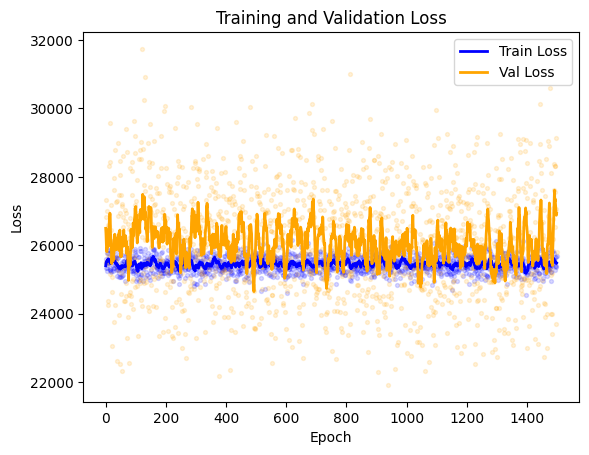

In [16]:
import matplotlib.pyplot as plt

train_loss = model.metrics[['epoch', 'epoch_train_loss']].dropna().reset_index(drop=True)
val_loss = model.metrics[['epoch', 'epoch_validation_loss']].dropna().reset_index(drop=True)

# Plot raw values as scatter points
plt.scatter(train_loss['epoch'], train_loss['epoch_train_loss'], color='blue', s=8, alpha=0.15)
plt.scatter(val_loss['epoch'], val_loss['epoch_validation_loss'], color='orange', s=8, alpha=0.15)

# Compute moving averages
train_loss_ma = train_loss['epoch_train_loss'].rolling(window=10, min_periods=1, center=True).mean()
val_loss_ma = val_loss['epoch_validation_loss'].rolling(window=10, min_periods=1, center=True).mean()

# Plot moving averages as lines
plt.plot(train_loss['epoch'], train_loss_ma, color='blue', linewidth=2, label='Train Loss')
plt.plot(val_loss['epoch'], val_loss_ma, color='orange', linewidth=2, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

啊？ 我做出来的图和他的完全不一样啊 它教程里面的还会下降 但是我做出来的这个完全不下降的呀 那这个训练有什么用？

In [17]:
model

scDiffEq[LightningSDE-FixedPotential-RegularizedVelocityRatio]

In [18]:
model.kNN

scDiffEq [INFO]: Bulding Annoy kNN Graph on adata.obsm['train']


kNN: X_pca

## Project the learned dynamics onto the original input data  将学习到的动态投影到原始输入数据上

In [19]:
model.drift()

scDiffEq [INFO]: Added: adata.obsm['X_drift']
scDiffEq [INFO]: Added: adata.obsm['drift']


In [20]:
model.diffusion()

scDiffEq [INFO]: Added: adata.obsm['X_diffusion']
scDiffEq [INFO]: Added: adata.obsm['diffusion']


## Make a stream plot  绘制流形图

Let's take a qualitative peek at the learned velocity. Here, we plot the learned drift function (the 2x512 fully-connected network) as the the vectory field. While we sample the diffusion field and plot the magnitude of diffusion and denote this using the colormap.  
让我们定性地观察一下所学到的速度。在此，我们将所学到的漂移函数（即 2x512 全连接网络）绘制为向量场。同时，我们对扩散场进行采样，绘制扩散幅值，并通过色图来表示。

First, we need to make the velocity graph - this is mostly borrowed from the `scvelo` implementation.  
首先，我们需要绘制速度曲线图——这主要借鉴了 `scvelo` 的实现。

In [21]:
sdq.tl.velocity_graph(model.adata)

scDiffEq [INFO]: Added: adata.obsp['distances']
scDiffEq [INFO]: Added: adata.obsp['connectivities']
scDiffEq [INFO]: Added: adata.uns['neighbors']
scDiffEq [INFO]: Added: adata.obsp['velocity_graph']
scDiffEq [INFO]: Added: adata.obsp['velocity_graph_neg']


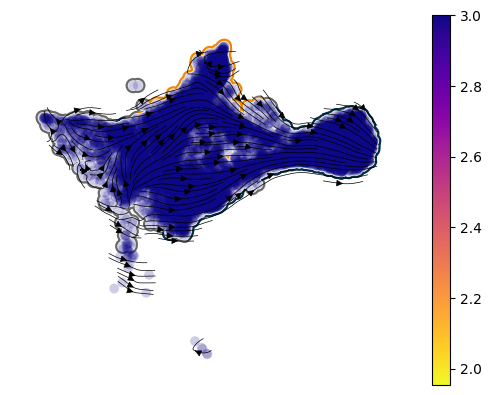

In [22]:
import cellplots

cmap = {
    "Undifferentiated": "dimgrey", #"#f0efeb",
    "Neutrophil": "#023047",
    "Monocyte": "#F08700",
}

axes = cellplots.umap_manifold(model.adata, groupby="Cell type annotation", c_background=cmap)
sdq.pl.velocity_stream(model.adata, c = "diffusion", ax=axes[0], scatter_kwargs={"vmax": 3})

## Sample and visualize trajectories  采样并可视化轨迹

We can generatively simulate trajectories from the original dataset and study them furhter to take on a granular view of the developmental dynamics. Here, we'll use `dt=0.1d`. The LARRY dataset provides measurements at multiple time points, allowing us to interpolate and extrapolate developmental trajectories with high temporal resolution.  
我们可以基于原始数据集生成式地模拟轨迹，并进一步研究这些轨迹，从而对发育动力学进行细致入微的观察。在此，我们将使用 `dt=0.1d`。LARRY 数据集提供了多个时间点的测量数据，这使我们能够以高时间分辨率对发育轨迹进行插值和外推。

### Isolate some early progenitor cells and sample a few to start from 分离出一些早期祖细胞，并取少量作为起始样本

In [23]:
progenitor = (
    model.adata.obs.loc[model.adata.obs["Time point"] == model.adata.obs["Time point"].min()]
    .loc[model.adata.obs["Cell type annotation"] == "Undifferentiated"]
    .sample(3)
)
progenitor

,Library,Cell barcode,Time point,Starting population,Cell type annotation,Well,SPRING-x,SPRING-y,clone_idx,fate_observed,t0_fated,nm_clones,W,train,test,fit_train,fit_val,drift,diffusion
2390,d2_2,TGCTTGGG-GGTCCCTT,2.0,Lin-Kit+Sca1-,Undifferentiated,0,256.944,424.535,3801.0,True,True,True,1,True,False,True,False,0.158327,6.383691
2334,d2_3,AATAAGGA-GAAGCACT,2.0,Lin-Kit+Sca1-,Undifferentiated,0,303.865,313.636,2693.0,True,True,True,1,True,False,True,True,0.159045,6.852625
4974,LSK_d2_1,GTCTTCCT-GCGCATTC,2.0,Lin-Kit+Sca1+,Undifferentiated,0,470.467,464.074,3560.0,True,True,True,1,True,False,False,False,0.140699,4.970232


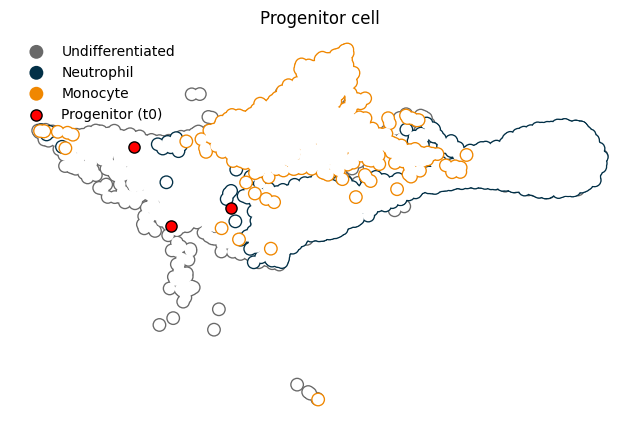

In [24]:
grouped = model.adata.obs.groupby("Cell type annotation")
x0 = model.adata[progenitor.index].obsm["X_umap"].toarray()

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for group in ["Undifferentiated", "Neutrophil", "Monocyte"]:
    group_ix = grouped.get_group(group).index
    xu = model.adata[group_ix].obsm["X_umap"]
    ax.scatter(xu[:, 0], xu[:, 1], c=cmap[group], label=group, ec = "None", rasterized=True, s = 100)
    ax.scatter(xu[:, 0], xu[:, 1], c="white", ec = "None", rasterized=True, s = 65)
ax.scatter(x0[:, 0], x0[:, 1], c="r", s=65, ec="k", label = "Progenitor (t0)")
ax.legend(facecolor="None", edgecolor="None")
ax.set_title("Progenitor cell")
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

In [25]:
adata_sim = sdq.tl.simulate(
    adata, idx=progenitor.index, N=512, diffeq=model.DiffEq, time_key="Time point"
)
print(adata_sim)

AnnData object with n_obs × n_vars = 62976 × 50
    obs: 't', 'z0_idx', 'sim_i', 'sim'
    uns: 'sim_idx', 'simulated'


"/data/cai803/scDiffEq/scDiffEq-main/src/scdiffeq/tools/_simulation.py"

问题的症结在于：**adata_sim 是模拟出来的数据，它只有 .X（基因表达矩阵），没有 .obsm['X_pca']（PCA空间坐标）。**  
model.kNN 是基于 PCA 空间构建的，它试图去 adata_sim 的 PCA 空间里找点，结果没找到，导致了内部逻辑混乱和长度不匹配。  
需要给 adata_sim 补上一个.obsm['X_pca']，让它看起来像是在 PCA 空间里就行了。  
"/data/cai803/scDiffEq/scDiffEq-main/src/scdiffeq/tools/_simulation.py"  -> adata_sim.X 实际上就是 PCA 空间的数据！

In [26]:
# 2. 直接赋值
# 因为 simulate 函数默认 use_key="X_pca"，所以输出就是 PCA 坐标
adata_sim.obsm['X_pca'] = adata_sim.X

"/data/cai803/scDiffEq/scDiffEq-main/src/scdiffeq/tools/_annotate_cell_state.py"

In [27]:
print(f"   - 原始数据 PCA 维度: {adata.obsm['X_pca'].shape}")
print(f"   - 模拟数据 PCA 维度: {adata_sim.obsm['X_pca'].shape}")

   - 原始数据 PCA 维度: (9350, 50)
   - 模拟数据 PCA 维度: (62976, 50)


In [28]:
# 检查 kNN 参数
print(f"kNN neighbors: {model.kNN._n_neighbors}")

kNN neighbors: 20


In [ ]:
sdq.tl.annotate_cell_state(adata_sim, kNN=model.kNN, obs_key="Cell type annotation")

**scDiffEq 的注释函数内部存在一个硬编码的逻辑错误，它错误地将 kNN 的邻居数量（20）当成了数据的维度（应该是 50）。**

src/scdiffeq/core/configs/_lightning_model_configuration.py 。  
具体位置：LightningModelConfiguration.__init__() 的参数列表。  
当前值：50。  
代码中明确写着 latent_dim: int = 50。这解释了为什么之前的 adata.obsm['X_pca'] 是 50 维，而之前的测试脚本试图用 20 维(model.kNN)会导致报错。

**逻辑： "/data/cai803/scDiffEq/scDiffEq-main/src/scdiffeq/tools/_annotate_cell_state.py" -》 "/data/cai803/scDiffEq/scDiffEq-main/src/scdiffeq/tools/_knn.py" from cell_neighbors import kNN  -》"/data/cai803/miniforge3/envs/scdiffeq/lib/python3.11/site-packages/cell_neighbors/_knn.py"  
Bug 原因：错误地使用 n_neighbors 作为 reshape 的参数，导致在处理非数值型（字符串）的注释数据时，NumPy 内存计算出错。  
解决方案：修改上述文件中的那一行代码，把 .reshape(-1, n_neighbors) 改为 .reshape(query_result.shape[0], n_neighbors)。**

In [29]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd

# 1. 在原始数据上构建 kNN（基于 50 维空间）
# 注意：这里 n_neighbors=20 是正常的，这是找邻居的数量，不是维度
knn = NearestNeighbors(n_neighbors=20, algorithm='auto')
knn.fit(adata.obsm['X_pca']) 

# 2. 查询：在原始数据中找模拟细胞的邻居
# 这里的 distances 和 indices 形状将是 (模拟细胞数, 20)
distances, indices = knn.kneighbors(adata_sim.obsm['X_pca'])

# 3. 投票：根据邻居的标签给模拟细胞打标签
original_labels = adata.obs['Cell type annotation'].values
predicted_labels = []

for i in range(indices.shape[0]):
    neighbor_indices = indices[i] # 这一行是 20 个邻居的索引
    neighbor_labels = original_labels[neighbor_indices] # 这是 20 个标签
    
    # 简单投票（取出现次数最多的标签）
    mode_label = pd.Series(neighbor_labels).mode()[0]
    predicted_labels.append(mode_label)

# 4. 写入结果
adata_sim.obs['Cell type annotation'] = predicted_labels
print("✅ 手动注释成功！")
print(adata_sim.obs['Cell type annotation'].value_counts())

✅ 手动注释成功！
Cell type annotation
Undifferentiated    62976
Name: count, dtype: int64


In [30]:
sdq.tl.annotate_cell_fate(adata_sim, state_key="Cell type annotation")

scDiffEq [INFO]: Added fate annotation: adata_sim.obs['fate']
scDiffEq [INFO]: Added fate counts: adata_sim.uns['fate_counts']


In [36]:
adata_sim.obs

,t,z0_idx,sim_i,sim,Cell type annotation,fate
0,2.0,2390,0,23900,Undifferentiated,Undifferentiated
1,2.0,2334,0,23340,Undifferentiated,Undifferentiated
2,2.0,4974,0,49740,Undifferentiated,Undifferentiated
3,2.0,2390,1,23901,Undifferentiated,Undifferentiated
4,2.0,2334,1,23341,Undifferentiated,Undifferentiated
...,...,...,...,...,...,...
62971,6.0,2334,510,2334510,Undifferentiated,Undifferentiated
62972,6.0,4974,510,4974510,Undifferentiated,Undifferentiated
62973,6.0,2390,511,2390511,Undifferentiated,Undifferentiated
62974,6.0,2334,511,2334511,Undifferentiated,Undifferentiated


模型真正预测的是fate annotation吗

scDiffEq 生成的带有细胞轨迹信息的值，是通过求解训练好的神经微分方程所得到的一系列连续的细胞状态向量（Cell State Vectors）。这些向量在降维图（如 UMAP）上连成的线，就是细胞轨迹。

轨迹信息在哪？  
就在这些训练好的神经网络权重里。当你运行 model.fit() 后，网络“记住”了细胞状态随时间变化的规律（即向量场）。  
模型通过学习，将静态的细胞映射到了动态的时间轴上。

In [31]:
adata_sim.uns["fate_counts"]

{'Undifferentiated': 1536}

Fit `UMAP` model to the training data

We can use `adata_sim.X` because our predictions (which are stored in `.X`) were made in the PCA space.

In [32]:
adata_sim.obsm["X_umap"] = UMAP.transform(adata_sim.X)

In [33]:
def plot_background(adata, ax):
    grouped = adata.obs.groupby("Cell type annotation")
    for group in ["Undifferentiated", "Neutrophil", "Monocyte"]:
        group_ix = grouped.get_group(group).index
        xu = model.adata[group_ix].obsm["X_umap"]
        ax.scatter(xu[:, 0], xu[:, 1], c=cmap[group], label=group, ec = "None", rasterized=True, s = 100)
        ax.scatter(xu[:, 0], xu[:, 1], c="white", ec = "None", rasterized=True, s = 65)
    ax.scatter(x0[:, 0], x0[:, 1], c="r", s=65, ec="k", label = "Progenitor (t0)")
    ax.legend(facecolor="None", edgecolor="None")


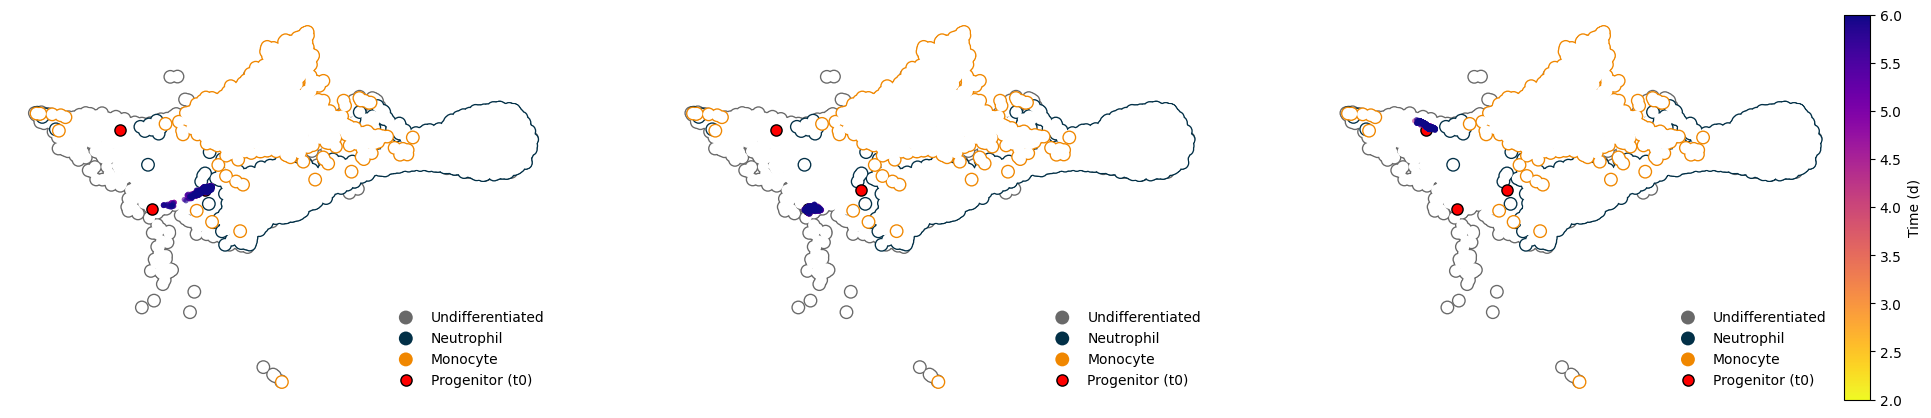

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(24, 5))


for en, (progenitor, group_df) in enumerate(adata_sim.obs.groupby("z0_idx")):
    ax = axes[en]
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
    plot_background(adata, ax)

    fate_subset = adata_sim[group_df.index]
    img = cellplots.umap(fate_subset, ax=ax, c=fate_subset.obs["t"], s=15, alpha=0.65, ec="None", cmap="plasma_r")

import numpy as np
import matplotlib.colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.05)

sm = plt.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=np.min(adata_sim.obs["t"]), vmax=np.max(adata_sim.obs["t"])), cmap="plasma_r")
sm.set_array([])
plt.colorbar(sm, cax=cax, label="Time (d)")

1. 背景（静态的真实世界）：  
画面上铺满了真实的单细胞数据点，展示了未分化细胞、单核细胞和中性粒细胞在 UMAP 空间中的真实分布位置。这代表了生物学事实的“终点”和“起点”分布。

2. 前景（动态的模拟轨迹）：  
在背景之上，画上了由模型生成的、按时间着色的细胞路径。   
验证模型：如果模型是准确的，这些模拟路径应该从红色的祖细胞区域（背景中的未分化细胞位置）出发，平滑地穿过 UMAP 空间，最终精准地落入背景中对应的“单核细胞”或“中性粒细胞”簇中。  
展示连续性：图中颜色的平滑渐变证明了模型不是在跳跃，而是学习到了连续的动态过程。

scDiffEq（基于神经微分方程）相对于 ScVelo（基于稳态假设或随机近似）的核心优势展示：它能生成具体的、连续的、像物理轨迹一样的细胞演化路径。

## Gene-level analyses

In [ ]:
scaler_model = sdq.io.read_pickle("/Users/mvinyard/data/scdiffeq_data/larry/scaler.pkl")
PCA = sdq.io.read_pickle("/Users/mvinyard/data/scdiffeq_data/larry/pca.pkl")

In [ ]:
sdq.tl.annotate_gene_features(adata_sim, adata, PCA=PCA, gene_id_key="gene_ids")
sdq.tl.invert_scaled_gex(adata_sim, scaler_model = scaler_model)

scDiffEq [INFO]: Gene names added to: `adata_sim.uns['gene_ids']`
scDiffEq [INFO]: Inverted expression added to: `adata_sim.obsm['X_gene']`


In [ ]:
adata_sim.uns['sim_idx'] = list(adata_sim.uns['sim_idx'])
adata_sim.uns["gene_ids"] = adata_sim.uns["gene_ids"].to_dict()

adata_sim.write_h5ad("./adata_sim.larry.h5ad")
print(adata_sim)

AnnData object with n_obs × n_vars = 62976 × 50
    obs: 't', 'z0_idx', 'sim_i', 'sim', 'Cell type annotation', 'fate'
    uns: 'sim_idx', 'simulated', 'fate_counts', 'gene_ids'
    obsm: 'X_umap', 'X_gene', 'X_gene_inv'


In [ ]:
import pandas as pd

def mean_and_std_expr(df, adata_sim, gene):
    x = adata_sim[df.index].obsm["X_gene_inv"][gene]
    return pd.Series({'mean': x.mean(), 'std': x.std()})

In [ ]:
genes = ["Gfi1", "Elane", "Mpo", "Gstm1", "Mmp8", "Gata2"]

means = []
stds = []
for gene in genes:
    res = adata_sim.obs.groupby(["t", "fate"]).apply(mean_and_std_expr, adata_sim=adata_sim, gene=gene)
    mean_df = res['mean'].unstack()
    std_df = res['std'].unstack()
    means.append(mean_df)
    stds.append(std_df)

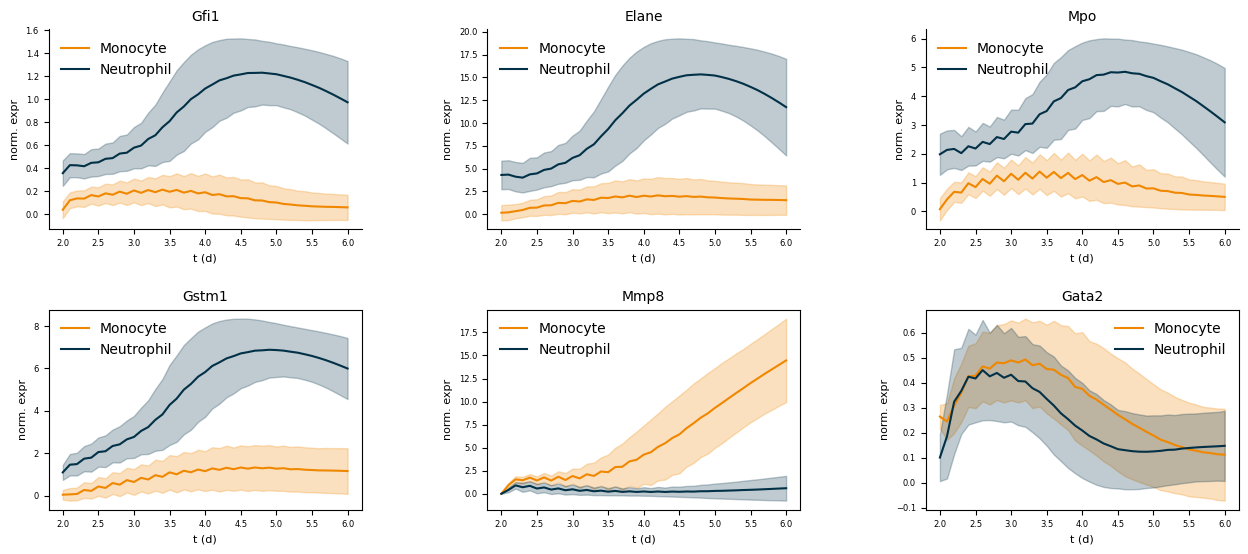

In [ ]:
fig, axes = cellplots.plot(
    6,
    3,
    height=0.65,
    width=0.8,
    wspace=0.4,
    hspace=0.4,
    x_label=["t (d)"],
    y_label=["norm. expr"],
    title=genes,
    delete=[["top", "right"]] * 3,
)

for en, (mean_df, std_df) in enumerate(zip(means, stds)):
    for col in mean_df:
        if col != "Undifferentiated":
            color = cmap[col]
            # Plot mean with line
            axes[en].plot(mean_df.index, mean_df[col], label=col, c=color)
            lower = mean_df[col] - std_df[col]
            upper = mean_df[col] + std_df[col]
            axes[en].fill_between(
                mean_df.index,
                lower,
                upper,
                color=color,
                alpha=0.25
            )
    axes[en].legend(facecolor="None", edgecolor="None")